https://www.perplexity.ai/search/you-are-a-python-instructor-fo-D8PzUjQ8SEC1obKOCCZ2vg#10

# Advanced Data Analysis with the Iris Dataset

This notebook performs statistical and machine learning exploration using the Iris dataset.
It demonstrates Pandas grouping and aggregation methods, regression models using Statsmodels, and classification using Scikit-learn.
Each code section includes detailed explanations of key functions and parameters.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set(style='whitegrid', palette='muted')

## 1. Loading and Inspecting the Dataset

We start by loading and summarizing the Iris dataset provided by Seaborn.

### Functions Explained
- `sns.load_dataset(name)`
  - `name`: string identifier of dataset; `'iris'` loads 150 labeled samples.
- `DataFrame.info()`
  - Displays data frame structure, dtypes, and non-null counts.
- `DataFrame.describe()`
  - Returns descriptive statistics including mean, standard deviation, quartiles, and max.


In [2]:
iris = sns.load_dataset('iris')
print(iris.info())
iris.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Correlation and Pairwise Relationships

A correlation matrix quantifies linear relationships between numeric variables.

### Functions and Parameters
- `DataFrame.corr(method='pearson', numeric_only=True)`
  - `method`: correlation method (`'pearson'`, `'spearman'`, `'kendall'`).
  - `numeric_only`: restrict computation to numeric columns.

- `sns.heatmap(data, annot=True, cmap='coolwarm', square=True)`
  - `data`: correlation matrix to visualize.
  - `annot`: displays numerical correlation values inside cells.
  - `cmap`: color palette; red/blue contrasts highlight positive or negative correlations.
  - `square`: makes cells square-shaped for readability.

- `sns.pairplot(data, hue, diag_kind)`
  - `data`: input DataFrame.
  - `hue`: categorical variable for color grouping.
  - `diag_kind`: type of plot on diagonal (`'kde'` or `'hist'`).


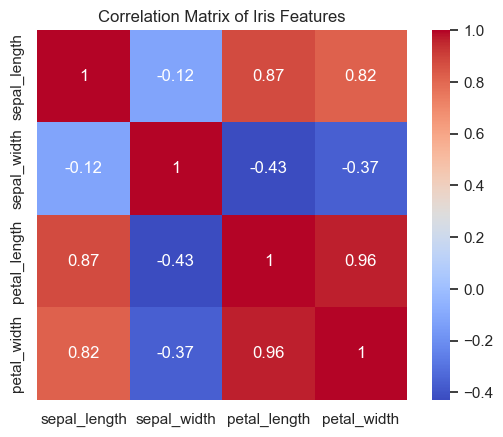

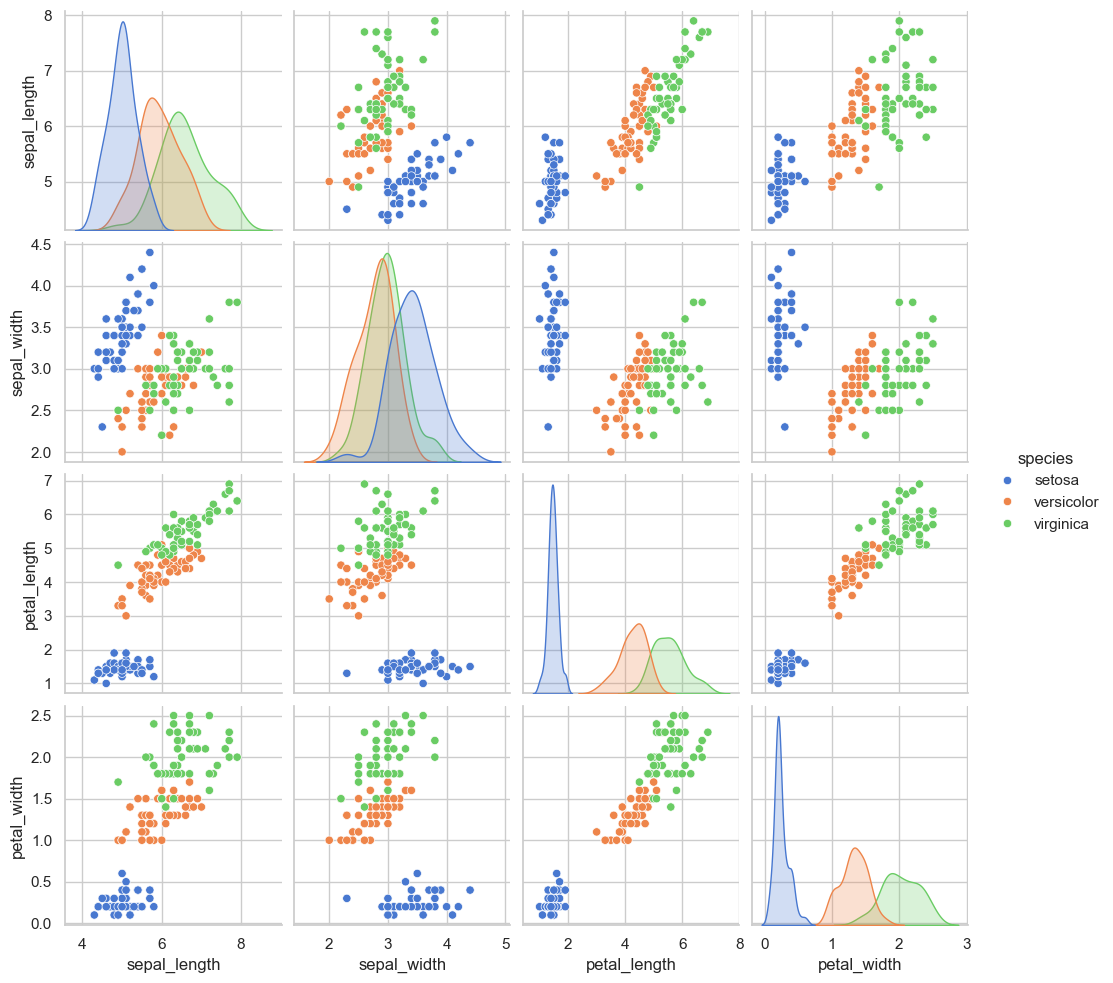

In [3]:
corr = iris.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Iris Features')
plt.show()

sns.pairplot(iris, hue='species', diag_kind='kde')
plt.show()

## 3. Grouped Statistics and Summary by Category

We compare feature statistics across species.

### Methods and Parameters
- `.groupby(by)`
  - `by`: column name(s) to group by (e.g., `'species'`).
- `.agg(func_list)`
  - `func_list`: list of functions or statistics to apply per column (`['mean','std','min','max']`).

### Visualization Function: `sns.boxplot()`
- `x`: category variable.
- `y`: continuous variable.
- `data`: DataFrame to pull data from.
- `palette`: color scheme for differentiation.

This boxplot reveals central tendencies and spread of petal length across species.

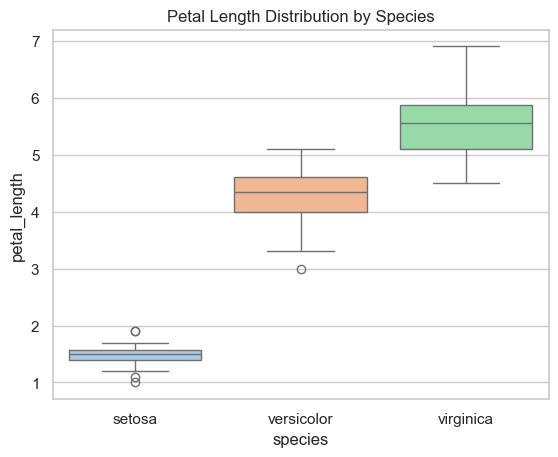

In [4]:
summary_by_species = iris.groupby('species').agg(['mean', 'std', 'min', 'max'])
summary_by_species

sns.boxplot(x='species', y='petal_length', data=iris, palette='pastel', hue = "species", legend = False)
plt.title('Petal Length Distribution by Species')
plt.show()

## 4. Linear Regression (Continuous Response)

We model relationships between numeric variables using Ordinary Least Squares (OLS).    
We model the sepal length based on the sepal width and petal length.

### Function: `smf.ols(formula, data)`
- `formula`: symbolic equation (example: `'sepal_length ~ sepal_width + petal_length'`).
  - Left side (`sepal_length`) is the dependent variable.
  - Right side lists independent predictors separated by `+`.
- `data`: DataFrame supplying variables.

### Method: `.fit()`
- Estimates model coefficients, standard errors, and diagnostics.

### `.summary()` Output Components
- **coef**: regression weights.
- **P>|t|**: p-value for statistical significance of each coefficient.
- **R-squared**: fraction of response variance explained by the model.
- **[0.025, 0.975]**: 95% confidence intervals for parameters.

### Visualization: `sns.lmplot()`
- `x`, `y`: define axes.
- `hue`: color group variable.
- `ci`: confidence interval around regression line (default 95%).
- Automatically fits linear regression for each group and plots fitted lines with confidence bands.

                            OLS Regression Results                            
Dep. Variable:           sepal_length   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     386.4
Date:                Mon, 03 Nov 2025   Prob (F-statistic):           2.93e-59
Time:                        08:58:43   Log-Likelihood:                -46.513
No. Observations:                 150   AIC:                             99.03
Df Residuals:                     147   BIC:                             108.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.2491      0.248      9.070   

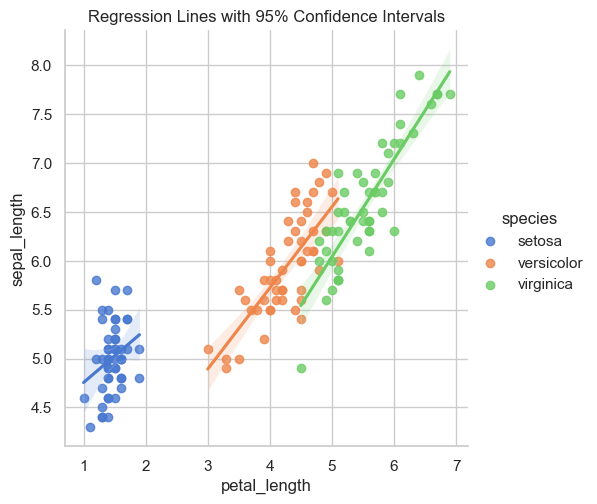

In [5]:
model = smf.ols('sepal_length ~ sepal_width + petal_length', data=iris).fit()
print(model.summary())

sns.lmplot(x='petal_length', y='sepal_length', hue='species', data=iris, ci=95)
plt.title('Regression Lines with 95% Confidence Intervals')
plt.show()

## 5. Logistic Regression (Binary Classification)

We predict whether a flower is *Setosa* or not.

### Scikit-learn Function Details
- `StandardScaler()`
  - Standardizes features by removing the mean and scaling to unit variance.
- `train_test_split(X, y, test_size, random_state)`
  - `X`: input features.
  - `y`: target labels.
  - `test_size`: proportion of data reserved for testing (0.3 = 30%).
  - `random_state`: ensures reproducible splits.
- `LogisticRegression(solver='lbfgs', max_iter=1000)`
  - `solver`: algorithm for optimization.
  - `max_iter`: maximum number of iterations during optimization.
- `.fit(X_train, y_train)`: trains the model.
- `.predict(X_test)`: generates classification predictions.

### Performance Metrics
- `classification_report(y_true, y_pred)`
  - Displays precision, recall, F1-score, and accuracy.
- `confusion_matrix(y_true, y_pred)`
  - 2x2 table comparing true positive/negative predictions.
- `sns.heatmap(data, annot=True, fmt='d', cmap='Blues')`
  - Visualizes confusion matrix counts.
  - `fmt='d'`: display integers.
  - `cmap`: defines colormap.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        19

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



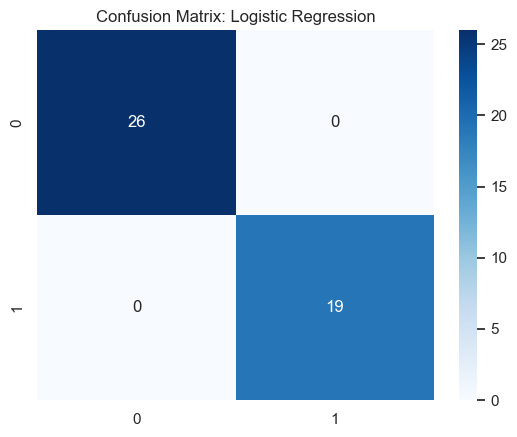

In [6]:
# classifier to determine if the class/category/flower species is setosa
# Create the issetosa column
iris['is_setosa'] = (iris['species'] == 'setosa').astype(int)
# use all 4 characteristics to classify the flowers  
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
# estimate the class as 0 or 1 - is setosa or not is setosa
y = iris['is_setosa']

# scale the data so characteristics with large or low values have the same weight in classification
# create a scaler
scaler = StandardScaler()
# transc=formathe data
X_scaled = scaler.fit_transform(X)

# split the data 30% testing 70% training
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# create the model
log_reg = LogisticRegression(solver='lbfgs', max_iter=1000)
# fit the model to the data
log_reg.fit(X_train, y_train)

# use the model to predict the class/category
y_pred = log_reg.predict(X_test)

# create a report with model evaluation metrics
print(classification_report(y_test, y_pred))

# create a heatmap of the confusion matrix
# true categories vs predicted categories
# this is a very good classifier based on the results
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

## 6. Interpretation of Statistical and Visual Outputs

### Linear Regression Key Interpretations
- **Coefficients**: represent unit change in dependent variable per unit change in predictors.
- **P-values**: measure evidence strength against null hypothesis (effect = 0).
- **Confidence intervals**: plausible ranges for parameter estimates.
- **R²**: percentage of response variance explained.

### Logistic Regression Interpretations
- **Coefficients (log-odds)** indicate directional influence of features on class probability.
- **Precision** = TP / (TP + FP): proportion of correct positive predictions.
- **Recall** = TP / (TP + FN): proportion of actual positives detected.
- **F1 Score**: harmonic mean of precision and recall.

### Visualization Parameters Recap
- Color palettes (e.g., `'pastel'`, `'coolwarm'`) communicate variation easily.
- `ci` (confidence interval) in Seaborn plots controls area shading precision.
- `annot` adds exact numerical values in heatmaps for interpretability.

Taken together, these models, metrics, and plots provide a comprehensive analysis of predictive and statistical patterns in the Iris dataset.